## Importing Dependencies

In [14]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Constrained Realizations Into Dataframe

In [15]:
filename = "./constrainedMilkyWay.hdf5"
output = "Output1"

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"

    data = {}
    for key in f[node_path].keys():
        data[key] = f[node_path][key][:]
    
    out_path = f"Outputs/{output}"
    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

# Add tree IDs

constrained_df["tree_id"] = -1
for i, start in enumerate(tree_start):
    count = tree_count[i]
    constrained_df.loc[start:start + count - 1, "tree_id"] = tree_index[i]

constrained_df["absolute_distance"] = np.sqrt(constrained_df["satellitePositionX"]**2 + constrained_df["satellitePositionY"]**2 + constrained_df["satellitePositionZ"]**2)

print(constrained_df["absolute_distance"].describe())
print(constrained_df.describe())

count    13290.000000
mean         0.369102
std          0.560739
min          0.000000
25%          0.106359
50%          0.185185
75%          0.333759
max          6.057486
Name: absolute_distance, dtype: float64
          basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count  1.329000e+04           13290.000000            13290.000000   
mean   1.282527e+10               6.811599                0.001940   
std    8.853659e+10               3.756728                0.002243   
min    1.005980e+08               0.362212                0.000219   
25%    3.518009e+08               3.664598                0.001016   
50%    7.694480e+08               6.354067                0.001396   
75%    2.224783e+09               9.853158                0.002069   
max    1.000000e+12              13.800484                0.051011   

       mergerTreeIndex     nodeIndex  nodeIsIsolated  nodeLabelIsLMCSubhalo  \
count     13290.000000  13290.000000    13290.000000           13290.00000

## Loading Unconstrained Realizations Into Dataframe

In [16]:
filename = "./unconstrainedMilkyWay.hdf5"
output = "Output1"

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"

    data = {}
    for key in f[node_path].keys():
        data[key] = f[node_path][key][:]
    
    out_path = f"Outputs/{output}"
    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

# Add tree IDs

unconstrained_df["tree_id"] = -1
for i, start in enumerate(tree_start):
    count = tree_count[i]
    unconstrained_df.loc[start:start + count - 1, "tree_id"] = tree_index[i]

print(unconstrained_df.describe())
print(unconstrained_df.columns)


          basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count  1.309900e+04           13099.000000            13099.000000   
mean   1.222750e+10               6.622552                0.001867   
std    8.894747e+10               3.758133                0.001881   
min    1.000875e+08               0.309911                0.000170   
25%    3.483565e+08               3.421227                0.001024   
50%    7.710992e+08               6.146548                0.001395   
75%    2.276966e+09               9.545182                0.002047   
max    1.000000e+12              13.800484                0.052459   

       mergerTreeIndex     nodeIndex  nodeIsIsolated  nodeSubsamplingWeight  \
count     13099.000000  13099.000000    13099.000000                13099.0   
mean         51.036186   3462.282006        0.007634                    1.0   
std          28.952640   4470.280935        0.087043                    0.0   
min           1.000000      1.000000        0.000000 

## Finding SMC Candidates In Constrained Data

In [17]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

min_smc_distance = 0.02
max_smc_distance = 0.04

smc_candidate_mask = (
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['basicMass', 'basicTimeLastIsolated', 'darkMatterProfileScale',
       'mergerTreeIndex', 'nodeIndex', 'nodeIsIsolated',
       'nodeLabelIsLMCSubhalo', 'nodeLabelLMC', 'nodeLabelWasLMCSubhalo',
       'nodeSubsamplingWeight', 'parentIndex', 'satelliteBoundMass',
       'satelliteIndex', 'satellitePositionX', 'satellitePositionY',
       'satellitePositionZ', 'satelliteTidalHeatingNormalized',
       'satelliteVelocityX', 'satelliteVelocityY', 'satelliteVelocityZ',
       'siblingIndex', 'spinAngularMomentum', 'spinAngularMomentumVectorX',
       'spinAngularMomentumVectorY', 'spinAngularMomentumVectorZ', 'tree_id',
       'absolute_distance'],
      dtype='object')
Selected tree IDs: [81, 48, 30]
Trees with multiple candidates: []
Trees with single candidate: [81, 48, 30]
Number selected: 3
Number of unique tree IDs: 3
Number of trees with multiple candidates: 0
Number of trees with single candidate: 3


## SMC Candidates of trees with Multiple Candidates

In [18]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 0


## SMC Candidates from trees with only one SMC

In [19]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 5


## Histograms of Infall times of Regular Candidates vs Special Candidates

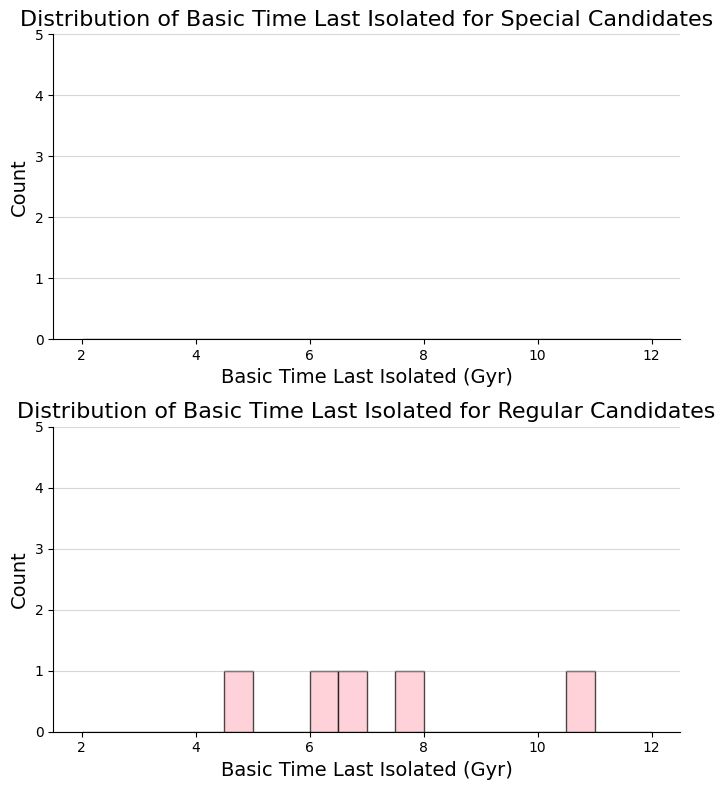

In [20]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Basic Time Last Isolated for Special Candidates", fontsize=16)
ax[0].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].set_ylim(0, 5)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Basic Time Last Isolated for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].set_ylim(0, 5)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



# Mass Function

## Cummulative Mass Function

In [21]:
def cum_mass(m_sub):
    n = 100
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx)/n
    return sorted_masses, N


## Generate X and Y From Constrained

In [22]:
constrained_m_sub = constrained_df["basicMass"].to_list()
constrained_x, constrained_y = cum_mass(constrained_m_sub)
print(constrained_x)
print(constrained_y)

[1.00598022e+08 1.00743899e+08 1.01154660e+08 ... 1.00000000e+12
 1.00000000e+12 1.00000000e+12]
[132.89 132.88 132.87 ...   0.     0.     0.  ]


## Generate X and Y From Unconstrained

In [23]:
unconstrained_m_sub = unconstrained_df["basicMass"].to_list()
unconstrained_x, unconstrained_y = cum_mass(unconstrained_m_sub)
print(unconstrained_x)
print(unconstrained_y)

[1.00087518e+08 1.00785212e+08 1.01749338e+08 ... 1.00000000e+12
 1.00000000e+12 1.00000000e+12]
[130.98 130.97 130.96 ...   0.     0.     0.  ]


## Make Mass Function Plot

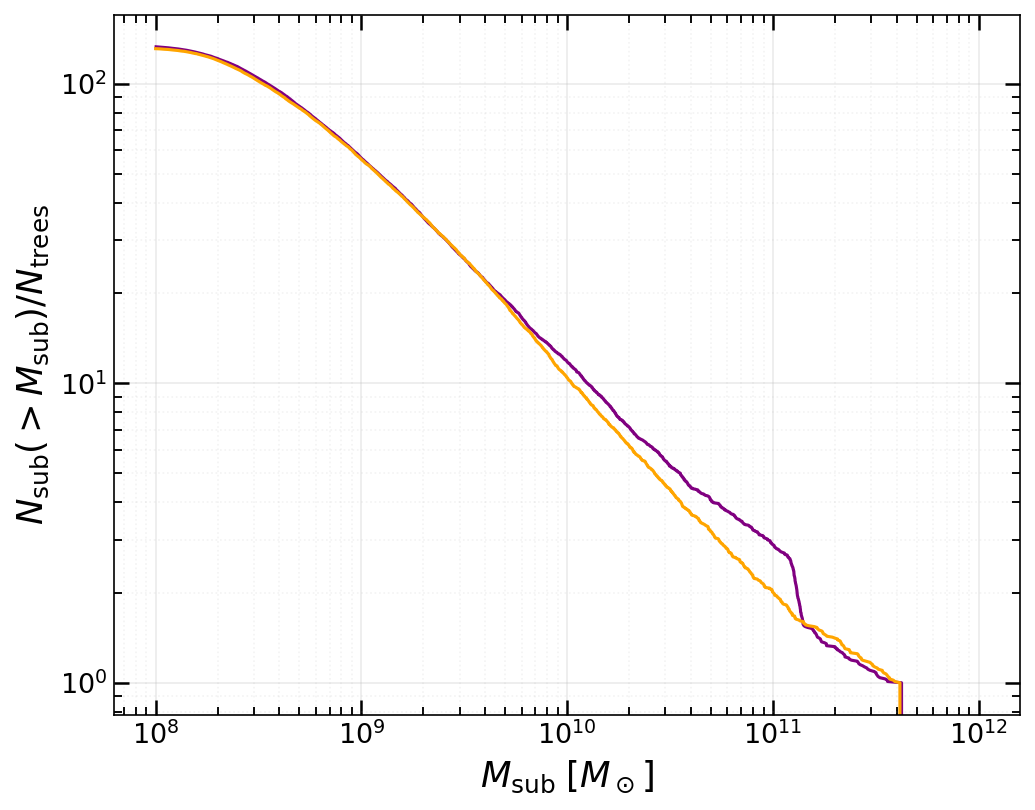

In [24]:
fig, ax = plt.subplots(figsize= (7, 5.5), dpi= 150)

ax.plot(constrained_x, constrained_y, color= "purple")
ax.plot(unconstrained_x, unconstrained_y, color= "orange")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax.set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax.tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax.tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax.tick_params(top=True, right=True, which="both")

ax.grid(True, which="major", linestyle="-", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos

In [25]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

[81, 48, 30]
[81, 81, 48, 30]
[]
Number of regular bound SMC candidates: 4
Number of special bound SMC candidates: 0
Number of bound SMC candidates: 3


## Including Distance in the definition of an SMC

In [26]:
min_distance = 50.0
max_distance = 100.0

distance_mask = (
    (selected["absolute_distance"] > min_distance) &
    (selected["absolute_distance"] < max_distance)
)

print(selected["absolute_distance"].describe())
print(selected["satellitePositionX"].describe())
print(selected["satellitePositionY"].describe())
print(selected["satellitePositionZ"].describe())

new_smc_cands = selected[distance_mask]

print(new_smc_cands.describe())

count    3.000000
mean     0.029867
std      0.007921
min      0.020816
25%      0.027032
50%      0.033247
75%      0.034392
max      0.035537
Name: absolute_distance, dtype: float64
count    3.000000
mean    -0.006711
std      0.029768
min     -0.031613
25%     -0.023197
50%     -0.014780
75%      0.005739
max      0.026259
Name: satellitePositionX, dtype: float64
count    3.000000
mean    -0.012421
std      0.010111
min     -0.022650
25%     -0.017415
50%     -0.012179
75%     -0.007306
max     -0.002433
Name: satellitePositionY, dtype: float64
count    3.000000
mean     0.001973
std      0.010373
min     -0.010002
25%     -0.001118
50%      0.007766
75%      0.007961
max      0.008156
Name: satellitePositionZ, dtype: float64
       basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count        0.0                    0.0                     0.0   
mean         NaN                    NaN                     NaN   
std          NaN                    NaN                     